# LAB 5: Naïve Bayes and Decision Tree Classification

**Aim:** Build Naïve Bayes and Decision Tree classification models and evaluate their performance using appropriate metrics.

## Experiment-1: Naïve Bayes Classification on Breast Cancer Dataset

Take breast cancer dataset and build a Naïve Bayes classification model using to predict class labels and evaluate its performance.

### 1) Load the dataset and split it into training and testing sets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Split into train and test sets (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset loaded successfully.")
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Dataset loaded successfully.
Training set size: (455, 30)
Testing set size: (114, 30)


### 2) Train a Naïve Bayes classifier

In [2]:
from sklearn.naive_bayes import GaussianNB

# Initialize and train Naive Bayes classifier
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)

print("Naïve Bayes classifier trained successfully.")

Naïve Bayes classifier trained successfully.


### 3) Predict class labels for the test data

In [3]:
# Predict on test data
y_pred_nb = nb_clf.predict(X_test)
y_prob_nb = nb_clf.predict_proba(X_test)[:, 1] # Probabilities for precision-recall curve

print("Predictions generated for the test data using Naïve Bayes.")

Predictions generated for the test data using Naïve Bayes.


### 4) Evaluate the model using Accuracy, Confusion Matrix, Classification Report, Precision-Recall Curve

Accuracy of Naïve Bayes: 0.9737

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        43
      benign       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



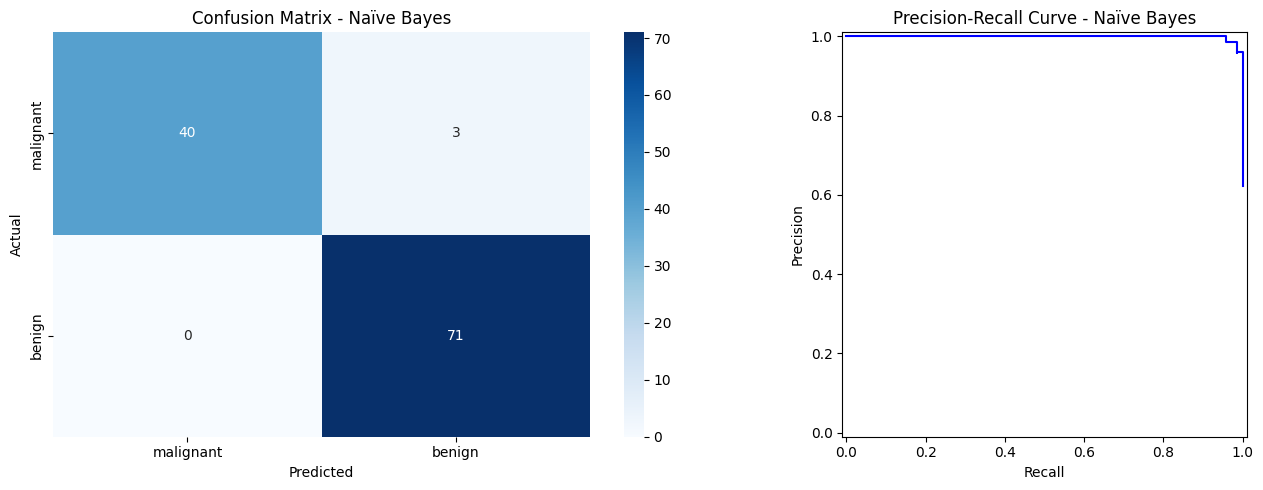

In [4]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_curve, PrecisionRecallDisplay

# Accuracy
acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Accuracy of Naïve Bayes: {acc_nb:.4f}\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_nb, target_names=data.target_names))

# Confusion Matrix and Precision-Recall Curve Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names, ax=axes[0])
axes[0].set_title('Confusion Matrix - Naïve Bayes')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Precision-Recall Curve
precision_nb, recall_nb, _ = precision_recall_curve(y_test, y_prob_nb)
pr_display = PrecisionRecallDisplay(precision=precision_nb, recall=recall_nb)
pr_display.plot(ax=axes[1], color='blue')
axes[1].set_title('Precision-Recall Curve - Naïve Bayes')

plt.tight_layout()
plt.show()

## Experiment-2: Decision Tree Classification

Build a Decision Tree classification model using the above dataset and evaluate its performance using appropriate metrics.

### 1) Load the dataset and split it into training and testing sets

In [5]:
# Re-using X_train, X_test, y_train, y_test from Experiment 1
print("Using previously generated training and testing splits.")

Using previously generated training and testing splits.


### 2) Train a Decision tree classifier

In [6]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train Decision Tree classifier
dt_clf = DecisionTreeClassifier(random_state=42, max_depth=4) # Limiting depth for better visualization
dt_clf.fit(X_train, y_train)

print("Decision Tree classifier trained successfully.")

Decision Tree classifier trained successfully.


### 3) Predict class labels for the test data

In [7]:
# Predict on test data
y_pred_dt = dt_clf.predict(X_test)
y_prob_dt = dt_clf.predict_proba(X_test)[:, 1]

print("Predictions generated for the test data using Decision Tree.")

Predictions generated for the test data using Decision Tree.


### 4) Evaluate the model using Accuracy, Confusion Matrix, Classification Report, Precision-Recall Curve, and tree visualization

Accuracy of Decision Tree: 0.9474

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



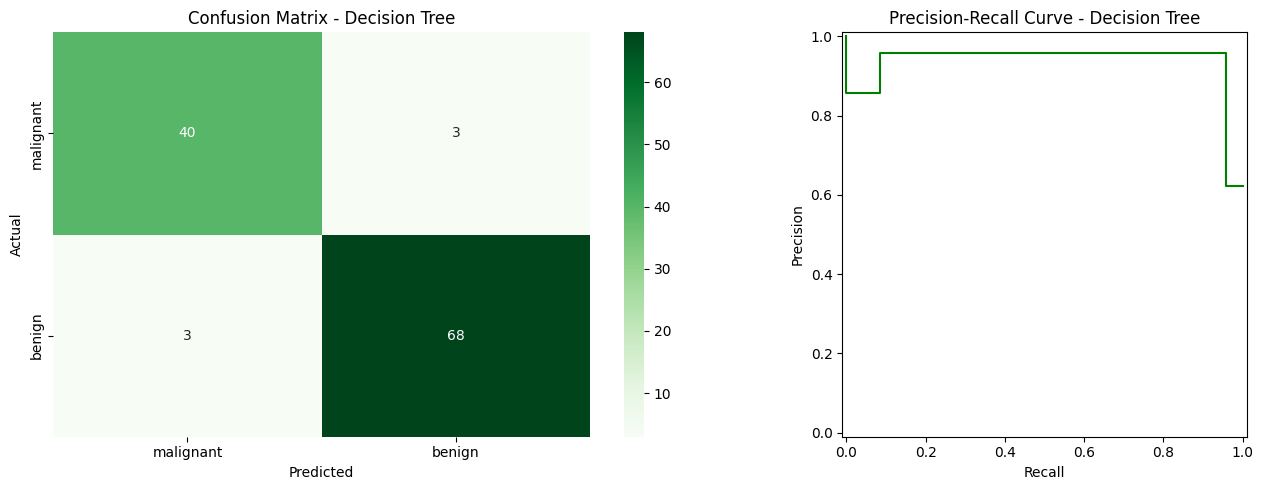

In [8]:
from sklearn.tree import plot_tree

# Accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Accuracy of Decision Tree: {acc_dt:.4f}\n")

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=data.target_names))

# Confusion Matrix and Precision-Recall Curve Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', xticklabels=data.target_names, yticklabels=data.target_names, ax=axes[0])
axes[0].set_title('Confusion Matrix - Decision Tree')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Precision-Recall Curve
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_prob_dt)
pr_display_dt = PrecisionRecallDisplay(precision=precision_dt, recall=recall_dt)
pr_display_dt.plot(ax=axes[1], color='green')
axes[1].set_title('Precision-Recall Curve - Decision Tree')

plt.tight_layout()
plt.show()

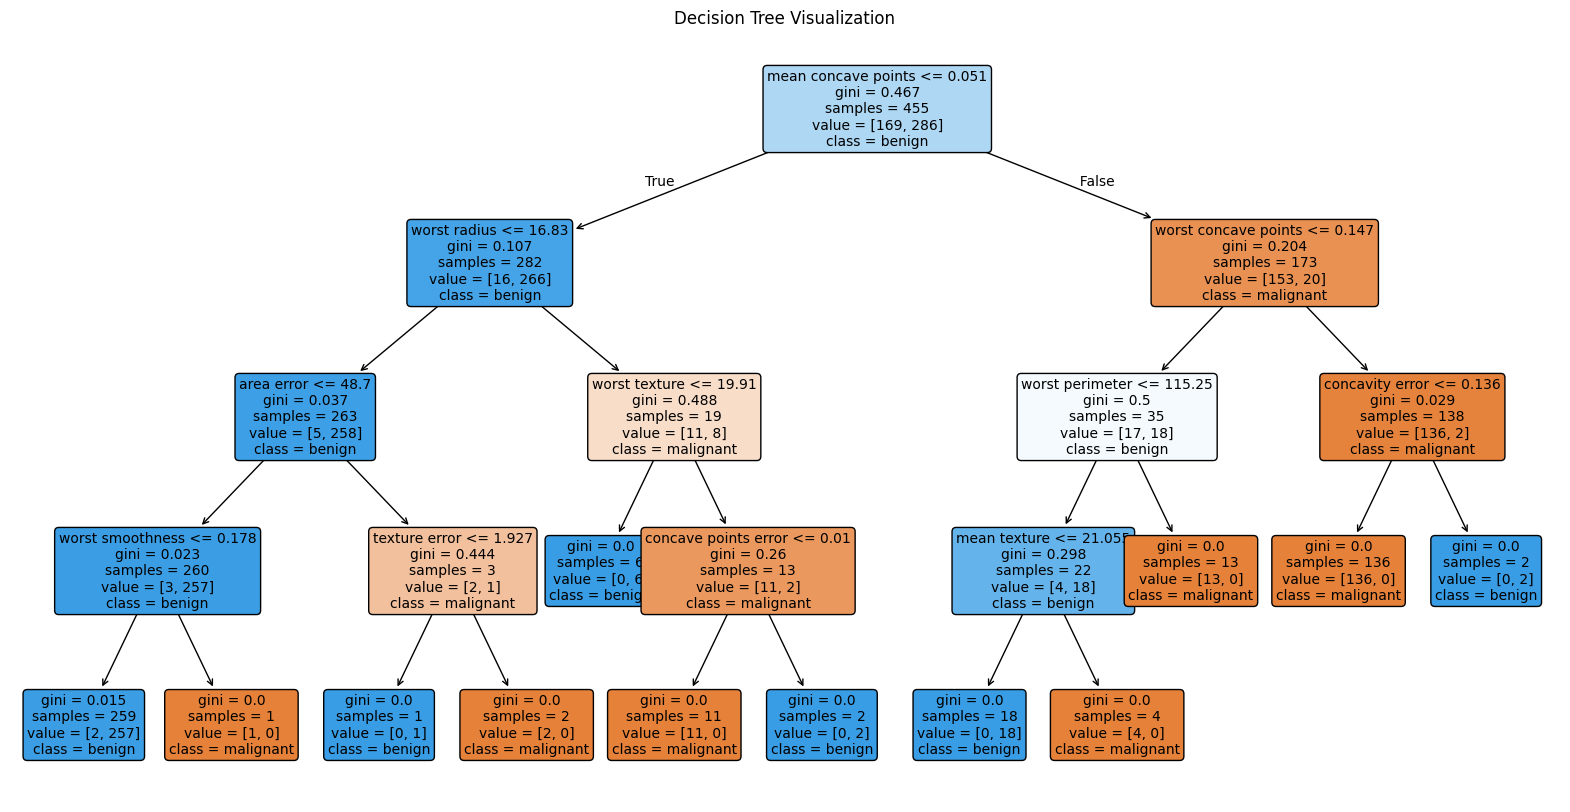

In [9]:
# Visualize Decision Tree
plt.figure(figsize=(20, 10))
plot_tree(dt_clf, feature_names=data.feature_names.tolist(), class_names=data.target_names.tolist(), filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Visualization")
plt.show()

## Experiment-3: Comparison of Naïve Bayes and Decision Tree Models

### Bar chart comparing training and testing accuracy of both models

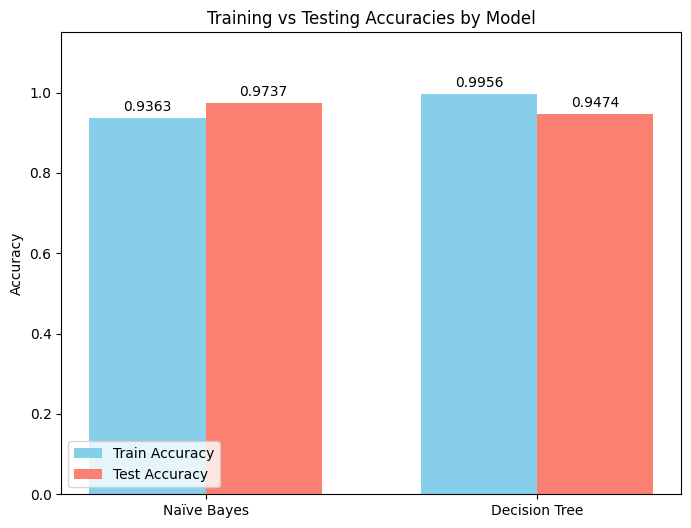

In [10]:
# Get training accuracies
train_acc_nb = accuracy_score(y_train, nb_clf.predict(X_train))
train_acc_dt = accuracy_score(y_train, dt_clf.predict(X_train))

models = ['Naïve Bayes', 'Decision Tree']
train_accuracies = [train_acc_nb, train_acc_dt]
test_accuracies = [acc_nb, acc_dt]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, train_accuracies, width, label='Train Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, test_accuracies, width, label='Test Accuracy', color='salmon')

ax.set_ylabel('Accuracy')
ax.set_title('Training vs Testing Accuracies by Model')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.15)
ax.legend(loc='lower left')

# Auto-label function for bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.4f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.show()

### ROC curve comparison for Naïve Bayes and Decision Tree

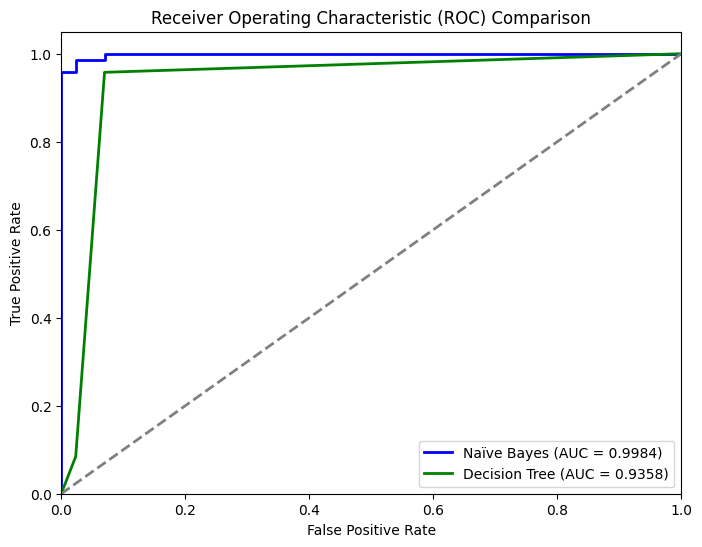

In [11]:
from sklearn.metrics import roc_curve, auc

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_nb, tpr_nb, color='blue', lw=2, label=f'Naïve Bayes (AUC = {roc_auc_nb:.4f})')
plt.plot(fpr_dt, tpr_dt, color='green', lw=2, label=f'Decision Tree (AUC = {roc_auc_dt:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.show()

### Confusion Matrix Heatmap (Side-by-Side) for both models

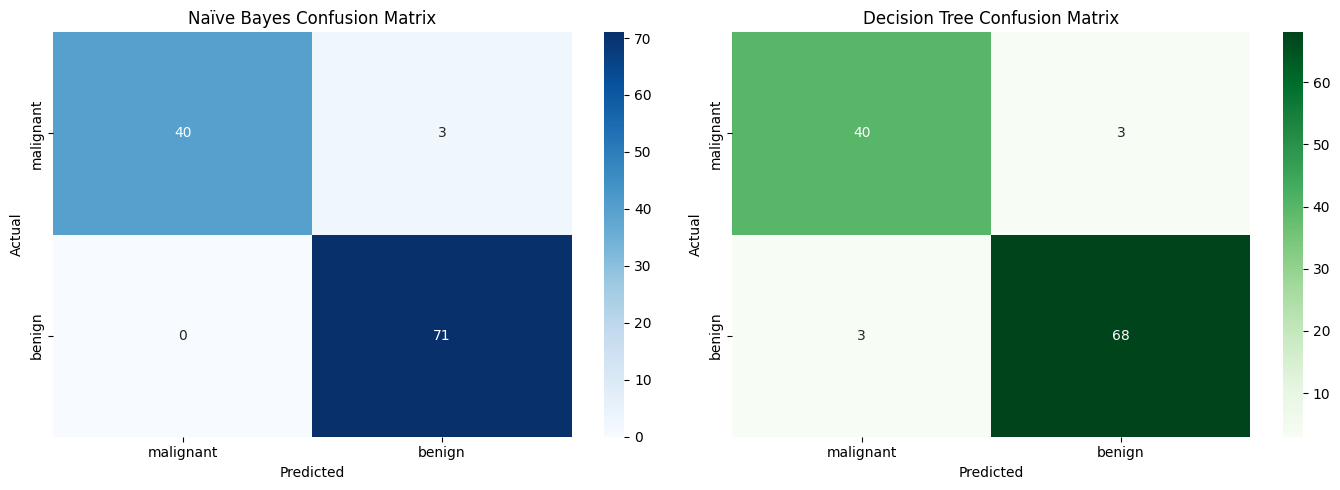

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Naive Bayes Confusion Matrix
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=data.target_names, yticklabels=data.target_names, ax=axes[0])
axes[0].set_title('Naïve Bayes Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree Confusion Matrix
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', xticklabels=data.target_names, yticklabels=data.target_names, ax=axes[1])
axes[1].set_title('Decision Tree Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()